# M2IB $\Rightarrow$ Better Visualiation via Multimodal Inforamtion Bottleneck


In [9]:
#openai CLIP module and grad-cam
!pip install git+https://github.com/openai/CLIP.git
!pip install grad-cam

  Cloning https://github.com/openai/CLIP.git to /private/var/folders/fz/1vyqty9d2gv7hzlj0kzxwrxr0000gn/T/pip-req-build-v1ow6eo6
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/fz/1vyqty9d2gv7hzlj0kzxwrxr0000gn/T/pip-req-build-v1ow6eo6
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


![alt text](image-1.png)

![alt text](image-2.png)

In [10]:
import warnings
warnings.filterwarnings('ignore')
import os
import torch
import clip
from M2IB.scripts.clip_wrapper import ClipWrapper
from M2IB.scripts.plot import visualize_vandt_heatmap
from M2IB.scripts.methods import vision_heatmap_iba, text_heatmap_iba
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizerFast
from PIL import Image, ImageOps
os.environ["TOKENIZERS_PARALLELISM"] = "false"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
tokenizer = CLIPTokenizerFast.from_pretrained("openai/clip-vit-base-patch32")

In [12]:
from PIL import Image
import requests
from io import BytesIO

def plot(model,image,text, vbeta=0.1, vvar=1, vlayer=9, tbeta=0.1, tvar=1, tlayer=9, bb=None): #bounding box

    # Preprocess image
    image = Image.open(image).convert('RGB')
    image_feat = processor(images=image, return_tensors="pt")['pixel_values'].to(device) # 3*224*224

    # Tokenize text
    text_ids = torch.tensor([tokenizer.encode(text, add_special_tokens=True)]).to(device)
    text_words = tokenizer.convert_ids_to_tokens(text_ids[0].tolist())

    # Train information bottleneck on image
    print("Training M2IB on the image...")
    vmap = vision_heatmap_iba(text_ids, image_feat, model, vlayer, vbeta, vvar)

    # Train information bottleneck on text
    print("Training M2IB on the text...")
    tmap = text_heatmap_iba(text_ids, image_feat, model, tlayer, tbeta, tvar)
    image_under = processor(images=image, return_tensors="pt", do_normalize=False)['pixel_values'][0].permute(1,2,0) # no normalization
    if bb:
        scaled_bb = []
        for x, y, w, h in bb:
            hr, vr = image_under.shape[0]/image.size[0], image_under.shape[1]/image.size[1]
            scaled_bb.append((x*hr, y*vr, w*hr, h*vr))
        bb = scaled_bb
    visualize_vandt_heatmap(tmap, vmap, text_words, image_under, bb=bb)

def download_and_process_image(image_url, output_filename="downloaded_image.jpg", new_width=300):
    try:
        # Fetch the image data
        response = requests.get(image_url, stream=True)
        response.raise_for_status()  # Raise an exception for bad status codes (4xx or 5xx)

        # Load the image using Pillow
        image = Image.open(BytesIO(response.content))

        # Process the image (example: resize)
        width, height = image.size
        new_height = int(height * (new_width / width))  # Maintain aspect ratio
        resized_image = image.resize((new_width, new_height))

        # Save the image
        resized_image.save(output_filename)
        print(f"Image downloaded, resized, and saved as {output_filename}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading image: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

# Tutorials: Visualization via Multimodal Information Bottleneck Principle

Image downloaded, resized, and saved as M2IB/images/cat.jpg
Training M2IB on the image...


Training Bottleneck: 100%|██████████| 10/10 [00:12<00:00,  1.23s/it]


Training M2IB on the text...


Training Bottleneck: 100%|██████████| 10/10 [00:10<00:00,  1.05s/it]


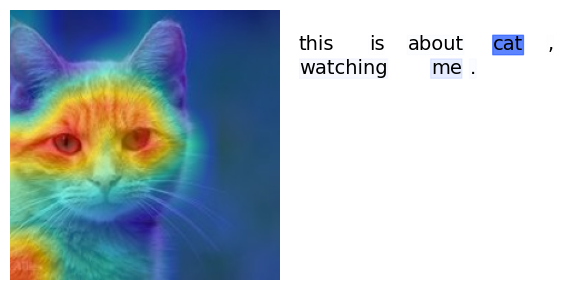

In [8]:
img_path = 'M2IB/images/cat.jpg'
download_and_process_image('https://www.alleycat.org/wp-content/uploads/2019/03/FELV-cat.jpg',img_path)

text = "This is about Cat, watching me."
plot(model, img_path, text)

Image downloaded, resized, and saved as M2IB/images/soccer.png
Training M2IB on the image...


Training Bottleneck: 100%|██████████| 10/10 [00:01<00:00,  9.81it/s]


Training M2IB on the text...


Training Bottleneck: 100%|██████████| 10/10 [00:00<00:00, 11.01it/s]


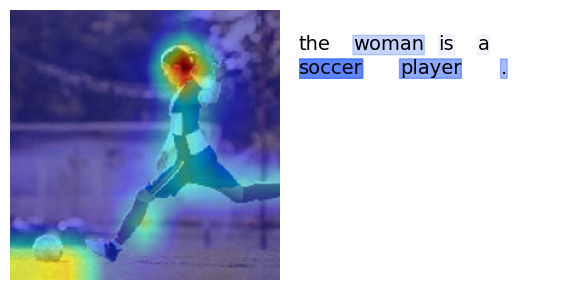

In [19]:
img_path = 'M2IB/images/soccer.png'
download_and_process_image('https://www.coachup.com/nation/wp-content/uploads/2018/06/cropped-637049378964878208iStock1095259340.png',img_path)

text = "The woman is a soccer player."
plot(model, img_path, text)

Training M2IB on the image...


Training Bottleneck: 100%|██████████| 10/10 [00:01<00:00,  7.75it/s]


Training M2IB on the text...


Training Bottleneck: 100%|██████████| 10/10 [00:01<00:00,  6.36it/s]


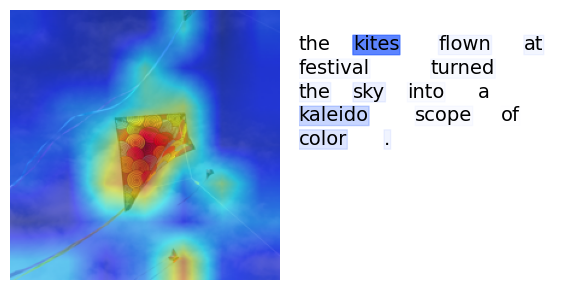

In [ ]:
img = "M2IB/images/kites.jpg"
text = "the kites flown at festival turned the sky into a kaleidoscope of color ."
plot(model, img, text)

Training M2IB on the image...


Training Bottleneck: 100%|██████████| 10/10 [00:01<00:00,  6.20it/s]


Training M2IB on the text...


Training Bottleneck: 100%|██████████| 10/10 [00:01<00:00,  9.97it/s]


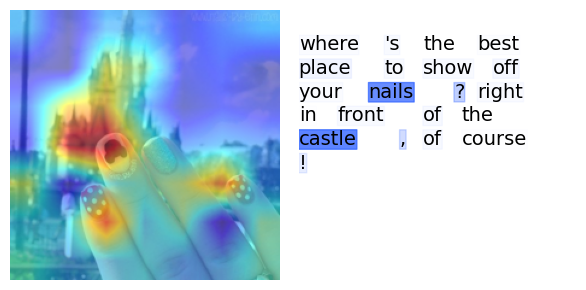

In [ ]:
img = "M2IB/images/castle.jpg"
text = "where 's the best place to show off your nails ? right in front of the castle , of course !"
plot(model, img, text)

# Another Tutorial: MS-CXR

To be able to run the following code, you need to first **download checkpoint finetuned on xray data from https://github.com/rajpurkarlab/CXR-RePaiR under the M2IB folder**.

In [ ]:
med_model, _ = clip.load("ViT-B/32", device=device)
med_model.load_state_dict(torch.load("M2IB/clip-imp-pretrained_128_6_after_4.pt", map_location=device))
med_model = ClipWrapper(med_model)

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 110MiB/s]


Training M2IB on the image...


Training Bottleneck: 100%|██████████| 10/10 [00:00<00:00, 11.01it/s]


Training M2IB on the text...


Training Bottleneck: 100%|██████████| 10/10 [00:00<00:00, 15.67it/s]


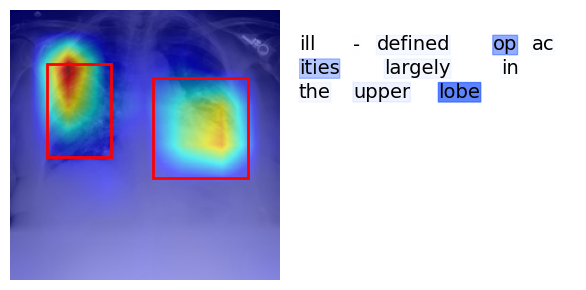

In [ ]:
img = "M2IB/images/cxr_upper.jpg"
text = "ill-defined opacities largely in the upper lobe"
bb = [(347,605,600,1052),(1337,765,899,1127)]
plot(med_model, img, text, vbeta = 1, vvar=1, vlayer=9, tbeta=1, tvar=1, tlayer=7, bb=bb)

Training M2IB on the image...


Training Bottleneck: 100%|██████████| 10/10 [00:00<00:00, 15.66it/s]


Training M2IB on the text...


Training Bottleneck: 100%|██████████| 10/10 [00:00<00:00, 15.40it/s]


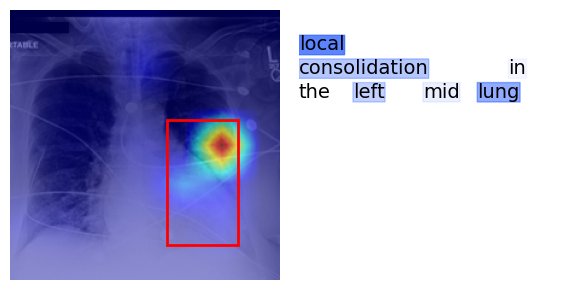

In [ ]:
img = "M2IB/images/cxr_left.jpg"
text = "local consolidation in the left midlung"
bb = [(1767,932,800,1063)]
plot(med_model, img, text, vbeta = 1, vvar=1, vlayer=9, tbeta=1, tvar=1, tlayer=7, bb=bb)